In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("16-multiclass_diabetes.csv")

In [3]:
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0
2,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0
3,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0
4,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0


Gender (Cinsiyet): Bireyin biyolojik cinsiyetini (0=Kadın, 1=Erkek) ifade eder ve hormonal veya yaşam tarzı farklılıklarından dolayı diyabet riskini etkileyebilir.

AGE (Yaş): Bireyin yaşını belirtir ve özellikle 45 yaşından sonra diyabet riskini doğrudan artıran kritik bir faktördür.

Urea (Üre): Kanda bulunan ve yüksekliği diyabetin yaygın komplikasyonlarından olan böbrek sorunlarına işaret edebilen üre miktarını ölçer.

Cr (Kreatinin): Böbrek fonksiyonlarının bir diğer önemli göstergesi olan ve yüksekliği diyabetle ilişkili böbrek hasarını düşündüren kandaki kreatinin seviyesini gösterir.

HbA1c (Glikozile Hemoglobin): Son 2-3 aylık ortalama kan şekeri seviyesini yüzde olarak gösteren ve kişinin diyabetik veya prediyabetik durumunu belirleyen temel belirteçtir.

Chol (Kolesterol): Kanda bulunan toplam kolesterol miktarını ifade eder ve yüksekliği diyabet hastalarında sık görülen kalp-damar hastalıkları için önemli bir risk faktörüdür.

TG (Trigliserit): Kandaki yağ (lipit) miktarını ölçer ve yüksekliği insülin direnci ile metabolik sendromla yakından ilişkilendirilir.

HDL (Yüksek Yoğunluklu Lipoprotein): Kan dolaşımındaki fazla kolesterolü temizlemeye yardımcı olduğu için seviyesinin yüksek olması istenen "iyi" kolesterol türüdür.

LDL (Düşük Yoğunluklu Lipoprotein): Damarlarda plak oluşumuna ve tıkanıklıklara katkıda bulunan, bu nedenle düşük olması hedeflenen "kötü" kolesterolü ifade eder.

VLDL (Çok Düşük Yoğunluklu Lipoprotein): Trigliseritleri taşıyan bir diğer "kötü" kolesterol türüdür ve yüksekliği artmış diyabet riski ile doğrudan bağlantılıdır.

BMI (Vücut Kitle İndeksi): Boy ve kiloya dayalı bir vücut yağ ölçümü olup, 30 ve üzeri olması (obezite) Tip 2 diyabet için çok büyük bir risk faktörü oluşturur.

Class (Sınıf): Veri setinin tahmin etmeye çalıştığı hedef değişkenidir ve kişinin diyabet hastası olmama (0), diyabet hastası olma (1) veya diyabete yatkın olma (2) durumunu sınıflandırır.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  264 non-null    int64  
 1   AGE     264 non-null    int64  
 2   Urea    264 non-null    float64
 3   Cr      264 non-null    int64  
 4   HbA1c   264 non-null    float64
 5   Chol    264 non-null    float64
 6   TG      264 non-null    float64
 7   HDL     264 non-null    float64
 8   LDL     264 non-null    float64
 9   VLDL    264 non-null    float64
 10  BMI     264 non-null    float64
 11  Class   264 non-null    int64  
dtypes: float64(8), int64(4)
memory usage: 24.9 KB


In [5]:
df.describe()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
count,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000,264.000000
mean,0.545455,49.522727,5.671515,85.806818,6.862727,4.594394,2.151894,1.182879,2.530871,1.479167,26.626856,1.121212
std,0.498875,10.127301,4.002837,99.400047,2.544604,1.289062,1.265841,0.455591,1.000173,3.099856,5.093652,0.914857
min,0.000000,25.000000,1.100000,6.000000,0.900000,0.000000,0.600000,0.400000,0.300000,0.200000,19.000000,0.000000
25%,0.000000,43.000000,3.600000,46.000000,5.000000,3.875000,1.300000,0.900000,1.800000,0.675000,23.000000,0.000000
50%,1.000000,50.000000,4.700000,61.000000,6.100000,4.500000,1.800000,1.100000,2.500000,0.900000,25.000000,1.000000
75%,1.000000,55.250000,6.100000,82.250000,8.200000,5.300000,2.725000,1.325000,3.200000,1.300000,30.000000,2.000000
max,1.000000,77.000000,26.400000,800.000000,14.600000,9.500000,8.700000,4.000000,5.600000,31.800000,43.250000,2.000000


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = df.drop('Class', axis = 1)
y = df['Class']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, shuffle=True)

In [9]:
X_train.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
144,0,56,1.9,20,11.7,5.5,5.3,0.9,1.3,1.2,33.0
73,0,50,6.0,61,5.0,4.4,2.7,1.3,3.1,1.1,21.0
78,1,36,3.3,70,4.2,4.9,2.5,0.9,1.9,0.7,20.0
252,1,55,26.4,228,7.1,4.1,1.9,1.3,2.0,0.9,27.0
182,1,60,5.0,55,10.0,4.5,1.3,0.9,3.0,0.6,33.0


In [10]:
y_train.head()

144    2
73     0
78     0
252    2
182    2
Name: Class, dtype: int64

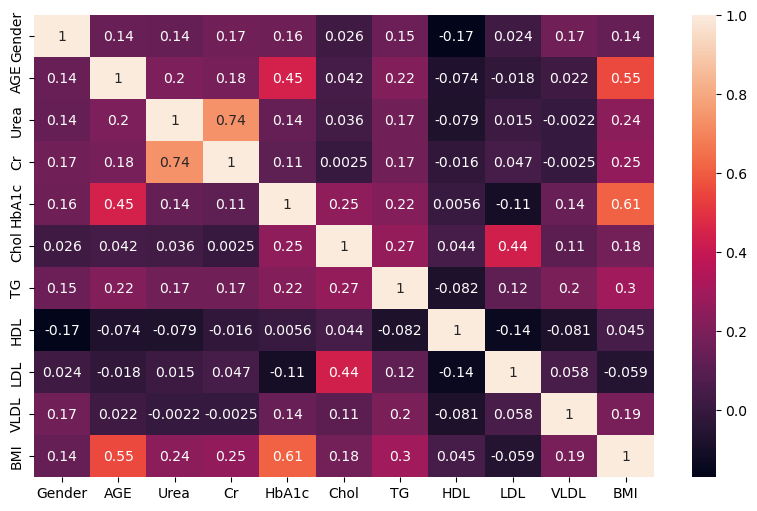

In [11]:
plt.figure(figsize = (10,6))
sns.heatmap(X.corr(), annot = True)
plt.show()

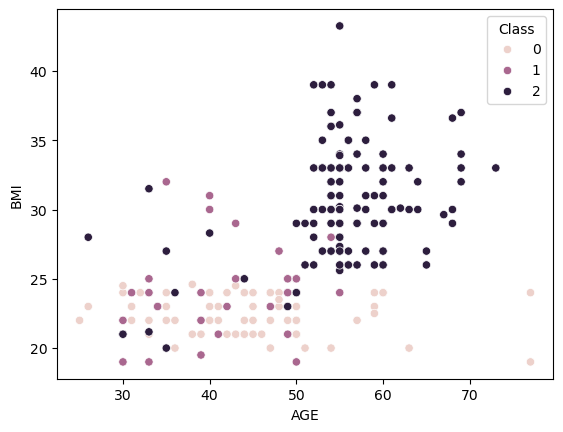

In [12]:
sns.scatterplot(data = df, x = 'AGE', y = 'BMI', hue = 'Class')
plt.show()

In [13]:
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [14]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.long)
y_test = torch.tensor(y_test, dtype = torch.long)

In [15]:
from torch import nn

In [107]:
class DiabetClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features = 11, out_features = 32),
            nn.ReLU(),
            
            nn.Linear(in_features = 32, out_features = 32),
            nn.ReLU(),
            
            nn.Linear(in_features = 32, out_features = 3)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [108]:
model = DiabetClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.01)

In [109]:
from torchmetrics.classification import MulticlassAccuracy

In [110]:
epochs = 400
accuracy = MulticlassAccuracy(3)
train_accuracy_values = []
test_accuracy_values = []
train_loss_values = []
test_loss_values = []

for epoch in range(epochs+1):
    ### Train Step
    model.train()
    # 1. Forward Pass
    y_logits = model(X_train)
    y_preds = torch.softmax(y_logits, dim = 1).argmax(dim = 1)

    # 2. Calculate Loss
    loss = loss_fn(y_logits, y_train)
    acc= accuracy(y_preds, y_train)

    # 3. Optimizer Zero Grad
    optimizer.zero_grad()

    # 4. Loss Backward
    loss.backward()

    # 5. Optimizer Step
    optimizer.step()

    train_accuracy_values.append(acc.item())
    train_loss_values.append(loss.item())
    

    ### Test Step
    model.eval()

    with torch.inference_mode():
        test_logits = model(X_test)
        test_preds = torch.softmax(test_logits, dim = 1).argmax(dim = 1)

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy(test_preds, y_test)

        test_accuracy_values.append(test_acc.item())
        test_loss_values.append(test_loss.item())


    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Train Accuracy: {acc:.2f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f} ")

Epoch: 0 | Train Loss: 2.8212 | Train Accuracy: 0.40 | Test Loss: 1.1024 | Test Accuracy: 0.38 
Epoch: 20 | Train Loss: 0.8296 | Train Accuracy: 0.50 | Test Loss: 0.8822 | Test Accuracy: 0.54 
Epoch: 40 | Train Loss: 0.5996 | Train Accuracy: 0.58 | Test Loss: 0.6835 | Test Accuracy: 0.60 
Epoch: 60 | Train Loss: 0.4629 | Train Accuracy: 0.71 | Test Loss: 0.6079 | Test Accuracy: 0.68 
Epoch: 80 | Train Loss: 0.3843 | Train Accuracy: 0.78 | Test Loss: 0.6234 | Test Accuracy: 0.71 
Epoch: 100 | Train Loss: 0.3265 | Train Accuracy: 0.85 | Test Loss: 0.6378 | Test Accuracy: 0.66 
Epoch: 120 | Train Loss: 0.2831 | Train Accuracy: 0.86 | Test Loss: 0.5770 | Test Accuracy: 0.65 
Epoch: 140 | Train Loss: 0.2413 | Train Accuracy: 0.89 | Test Loss: 0.5983 | Test Accuracy: 0.71 
Epoch: 160 | Train Loss: 0.2124 | Train Accuracy: 0.86 | Test Loss: 0.6491 | Test Accuracy: 0.78 
Epoch: 180 | Train Loss: 0.1772 | Train Accuracy: 0.95 | Test Loss: 0.6002 | Test Accuracy: 0.79 
Epoch: 200 | Train Loss: 0

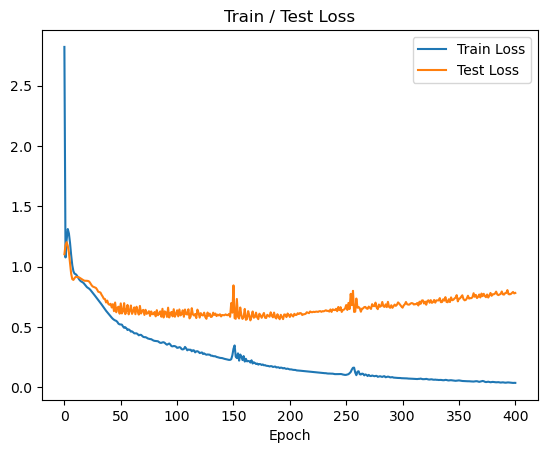

In [111]:
plt.plot(train_loss_values, label = 'Train Loss')
plt.plot(test_loss_values, label = 'Test Loss')
plt.title('Train / Test Loss')
plt.xlabel("Epoch")
plt.legend()
plt.show()

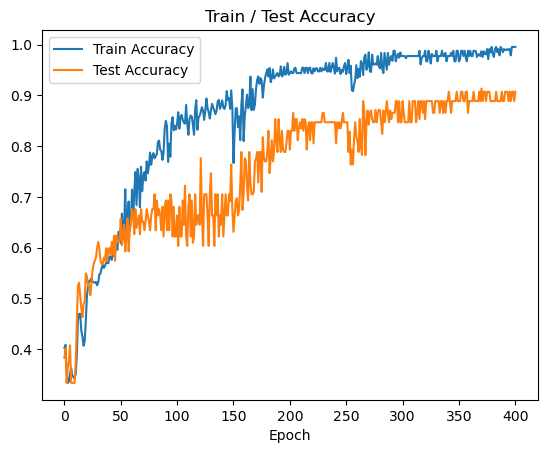

In [112]:
plt.plot(train_accuracy_values, label = 'Train Accuracy')
plt.plot(test_accuracy_values, label = 'Test Accuracy')
plt.title('Train / Test Accuracy')
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [113]:
from torchmetrics.utilities.plot import plot_confusion_matrix
from torchmetrics.classification import MulticlassConfusionMatrix

In [114]:
cm = MulticlassConfusionMatrix(3)
matrix = cm(test_preds, y_test)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

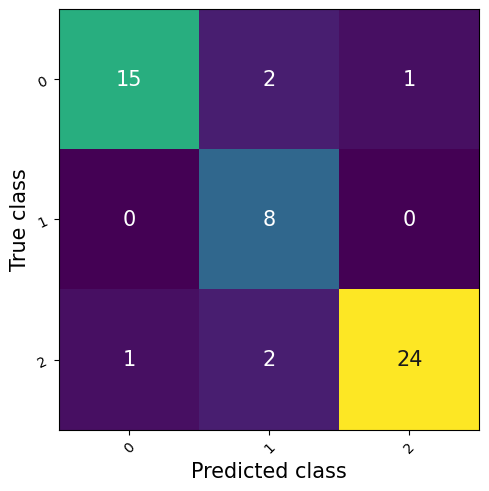

In [115]:
plot_confusion_matrix(matrix)

In [116]:
from pathlib import Path

In [117]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

MODEL_NAME = "diabet_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj = model.state_dict(), f = MODEL_SAVE_PATH)